In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

In [3]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


I guess this is the information of passengers but i dont understand what "Survived" column means


In [6]:
print(f'Size: {df.shape}')
print(f'Rows: {df.shape[0]}, columns: {df.shape[1]}')

Size: (891, 12)
Rows: 891, columns: 12


Dataset has 891 passengers and 12 columns


In [9]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


0,1,2,6,7 columns has integer data type;
3,4,8,10,11 columns has object data type (usually Strings);
5,9 columns has float data types;
There is missing data at age, cabin, and, embarked columns;

In [20]:
df.isnull().sum().sort_values(ascending=False)

Cabin          687
Age            177
Embarked         2
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
SibSp            0
Parch            0
Ticket           0
Fare             0
dtype: int64

the most amounf of missing data is in cabin columns with 687 


In [23]:
df.describe().round(3)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000,891.000,891.000,714.000,891.000,891.000,891.000
mean,446.000,0.384,2.309,29.699,0.523,0.382,32.204
std,257.354,0.487,0.836,14.526,1.103,0.806,49.693
min,1.000,0.000,1.000,0.420,0.000,0.000,0.000
25%,223.500,0.000,2.000,20.125,0.000,0.000,7.910
50%,446.000,0.000,3.000,28.000,0.000,0.000,14.454
75%,668.500,1.000,3.000,38.000,1.000,0.000,31.000
max,891.000,1.000,3.000,80.000,8.000,6.000,512.329


average age of passengers is 30;


In [24]:
df['Survived'].value_counts()


Survived
0    549
1    342
Name: count, dtype: int64

In [27]:
survival_rate = df['Survived'].mean()
print(f'Survived: {survival_rate:.1%}')

Survived: 38.4%


In [34]:
survived_sex = df.groupby('Sex')['Survived'].mean()
print(f'Female: {survived_sex['female']:.1%}')
print(f'Male: {survived_sex['male']:.1%}')

Female: 74.2%
Male: 18.9%


Percentage of survived females is by far higher then male with 74.2% of females survived and 18.9% males survived

In [85]:
df.groupby('Pclass')['Survived'].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

In [44]:
df.groupby(['Sex', 'Pclass'])['Survived'].mean().round(2)


Sex     Pclass
female  1         0.97
        2         0.92
        3         0.50
male    1         0.37
        2         0.16
        3         0.14
Name: Survived, dtype: float64

In [46]:
df.groupby('Survived')['Age'].mean().round(2)

Survived
0    30.63
1    28.34
Name: Age, dtype: float64

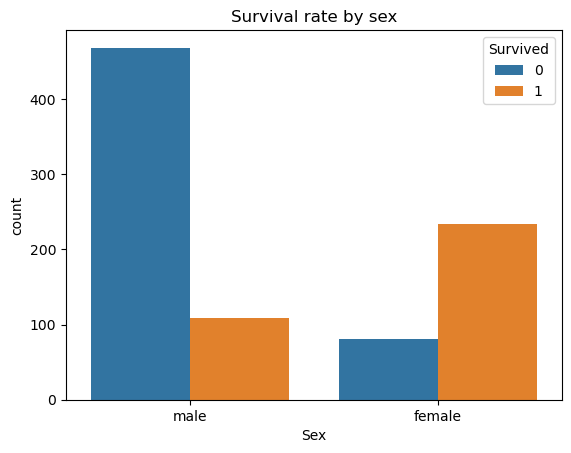

In [53]:
sns.countplot(data=df, x='Sex', hue='Survived')
plt.title("Survival rate by sex")
plt.show()



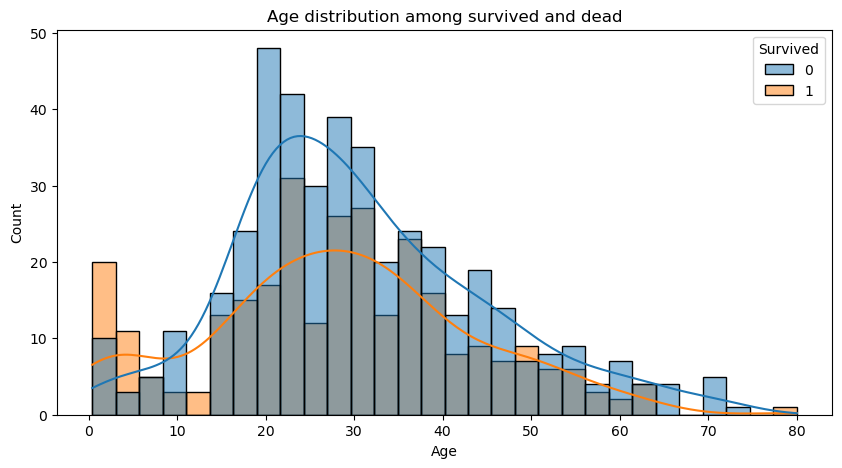

In [66]:
plt.figure(figsize=(10,5))
sns.histplot(data=df, x="Age", hue='Survived', bins=30, kde=True)
plt.title("Age distribution among survived and dead")
plt.show()

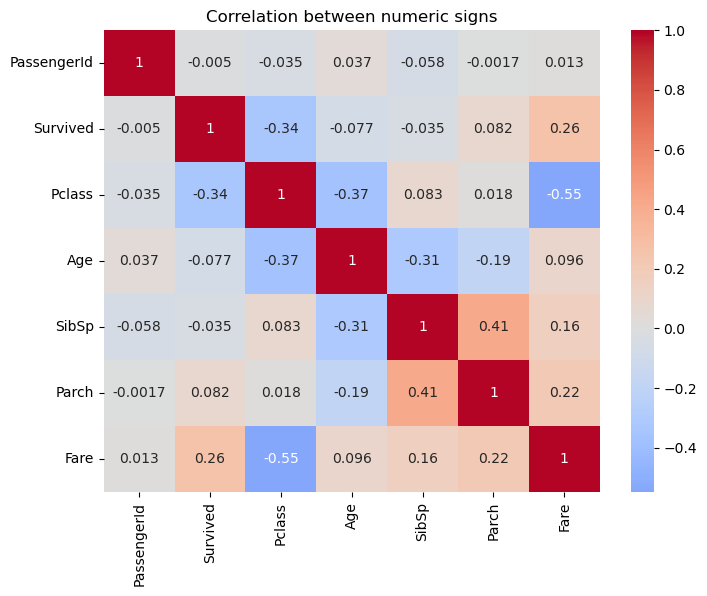

In [79]:
numeric_df = df.select_dtypes(include="number")
plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Correlation between numeric signs')
plt.show()

## Conclusions
1. There are a lot of passengers who is 20-30 years old
2. Female 1 class passengers survived the most, meanwhile male 3 class passengers survived the least
3. Overall, passengers who are 20 years old survived the most
4. Percentage of females who survived is more then of male passengers
5. In total, count of dead male passengers is much more then of dead female passengers
   